<a href="https://colab.research.google.com/github/sofol-bit/LinSofoNEUR265/blob/main/homework/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lindsey Sofo
*Introduction to Neural Data Analysis*

**March 5th, 2026**

In [1]:
#imports

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [5]:
#import pandas df/checking

patch_seq = pd.read_csv('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv')
print(patch_seq)

           ISI  Fast_Trough Marker
0    77.337143   -49.899998    Sst
1    17.177895   -44.462498    Sst
2    48.294737   -47.350002    Sst
3     8.980000   -45.656254    Sst
4    30.315385   -50.737499    Sst
..         ...          ...    ...
360  11.052333   -54.743752  Pvalb
361   8.860360   -64.875008  Pvalb
362   9.192897   -51.312504  Pvalb
363  10.544731   -52.281254  Pvalb
364  16.396364   -61.437504  Pvalb

[365 rows x 3 columns]


Text(0, 0.5, 'Count')

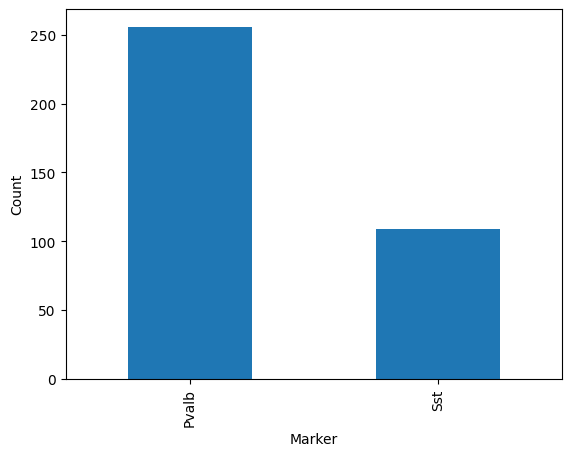

In [17]:
#create bar graph with counts of each marker gene from marker column

patch_seq['Marker'].value_counts().plot(kind='bar')
plt.xlabel('Marker')
plt.ylabel('Count')

<Axes: ylabel='count'>

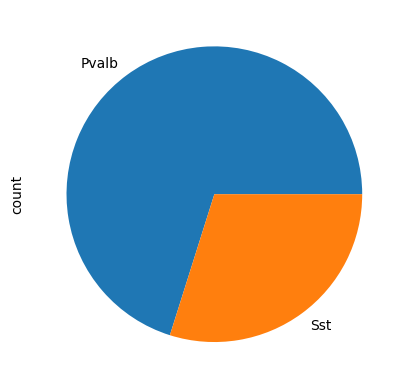

In [18]:
#same data as above displayed as pie chart

patch_seq['Marker'].value_counts().plot(kind='pie')

Text(0, 0.5, 'Fast_Trough')

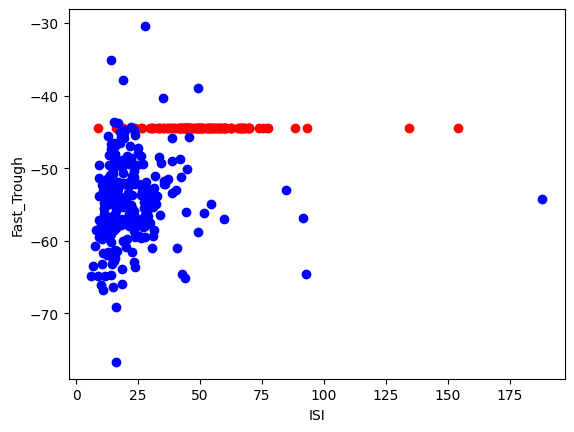

In [11]:
#for loop to produce scatter plot of ISI on x axis and FT on y, with Sst in red and Pvalb in blue

for i in range(len(patch_seq)):
  if patch_seq['Marker'].iloc[i] == 'Sst':
    plt.scatter(patch_seq['ISI'].iloc[i], patch_seq['Fast_Trough'].iloc[1], color='red')
  elif patch_seq['Marker'].iloc[i] == 'Pvalb':
    plt.scatter(patch_seq['ISI'].iloc[i], patch_seq['Fast_Trough'].iloc[i], color='blue')

plt.xlabel('ISI')
plt.ylabel('Fast_Trough')

In [14]:
#create function to create scatter plot created above

def patchScatter():
  """
  fucntion to plot a scatterplot with ISI and fast trough values, with Sst in red and Pvalb in blue
  """
  for i in range(len(patch_seq)):
    if patch_seq['Marker'].iloc[i] == 'Sst':
     plt.scatter(patch_seq['ISI'].iloc[i], patch_seq['Fast_Trough'].iloc[1], color='red')
    elif patch_seq['Marker'].iloc[i] == 'Pvalb':
      plt.scatter(patch_seq['ISI'].iloc[i], patch_seq['Fast_Trough'].iloc[i], color='blue')

  plt.xlabel('ISI')
  plt.ylabel('Fast_Trough')
  plt.show()


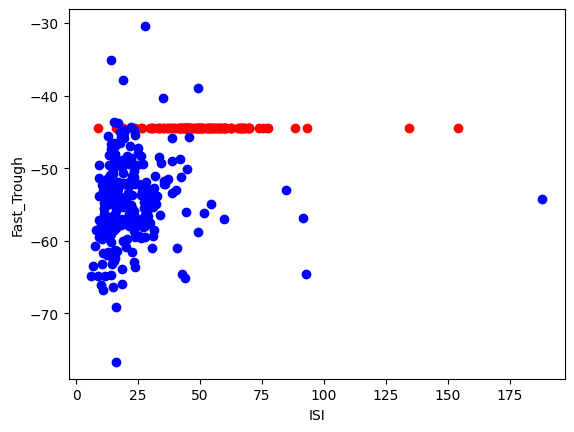

In [15]:
#call function

patchScatter()

In [19]:
#find mean, SD, and range of FT from Sst and Pvalb

patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


Pvalb has more negative undershoot, though the two are close in value (-2 difference)

In [20]:
#calculate skew of FT for Sst and Pvalb

patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


Both distributions are normal (between -0.5 and 0.5)

In [22]:
#find mean, SD, and range of ISI from Sst and Pvalb

patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


Both markers have a skewed distribution for ISI (greater than 0.5)

In [24]:
#t test to see if FT and ISI differ between Sst and Pvalv

sst_neurons = patch_seq[patch_seq['Marker']=='Sst']
pvalb_neurons = patch_seq[patch_seq['Marker']=='Pvalb']

stats.ttest_ind(sst_neurons['Fast_Trough'], pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

Yes, the FT values differ significantly. Pvalue=0.00168 which is less that 0.05.

In [29]:
#ttest for ISI, new variables due to missing data

sst = sst_neurons['ISI'].dropna()
pvalb = pvalb_neurons['ISI'].dropna()

stats.ttest_ind(sst, pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

Diff in ISI values is sig, pvalue < 0.05